In [1]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "bmw.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "mysarahmadbhat/bmw-used-car-listing",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

print("First 5 records:", df.head())

/tmp/ipykernel_1379/3864816505.py:10: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


100%|██████████| 579k/579k [00:00<00:00, 645kB/s]

First 5 records:        model  year  price transmission  mileage fuelType  tax   mpg  \
0   5 Series  2014  11200    Automatic    67068   Diesel  125  57.6   
1   6 Series  2018  27000    Automatic    14827   Petrol  145  42.8   
2   5 Series  2016  16000    Automatic    62794   Diesel  160  51.4   
3   1 Series  2017  12750    Automatic    26676   Diesel  145  72.4   
4   7 Series  2014  14500    Automatic    39554   Diesel  160  50.4   

   engineSize  
0         2.0  
1         2.0  
2         3.0  
3         1.5  
4         3.0  


Neural Networks:
input features -> hidden layers -> output

Neurons: each neuron takes all inputs from previous layer, mutliplies each 1 by a weight, adds them all together, and passes result through an activiation function

Weights = what network is actually learning it starts with random weights and gradually adjusts them to minimise prediction error

How it learns: makes a prediction, measures how wrong it was (loss) then works backwards through the networks to adjust all of the weights to reduce error [backpropagation]
= this is repeated thousands of times

Neural network learns by repeatedly refining its weights through trial and error

Multiple layers of weights on top of each other = can capture highly complex non-linear patterns

In [ ]:
df.columns= df.columns.str.strip()
print(df.columns.tolist())

#removing year and instead changing this to car age
df["age"] = 2024 - df["year"]

['model', 'year', 'price', 'transmission', 'mileage', 'fuelType', 'tax', 'mpg', 'engineSize']


In [ ]:
#defining input features
#removing year and replacing it with age = we do this because of scaling in future
X= df[["model", "age", "transmission", "mileage", "fuelType", "tax", "mpg", "engineSize" ]]

#defining target/outcome variable - what we want to predict
y= df["price"]

#y is a continuous number rather than a category = regression problem not classification problem

#confirmation
print(X.head())


       model  age transmission  mileage fuelType  tax   mpg  engineSize
0   5 Series   10    Automatic    67068   Diesel  125  57.6         2.0
1   6 Series    6    Automatic    14827   Petrol  145  42.8         2.0
2   5 Series    8    Automatic    62794   Diesel  160  51.4         3.0
3   1 Series    7    Automatic    26676   Diesel  145  72.4         1.5
4   7 Series   10    Automatic    39554   Diesel  160  50.4         3.0


In [ ]:
import pandas as pd

X_encoded = pd.get_dummies(X, dtype=int)
X_encoded

,age,mileage,tax,mpg,engineSize,model_ 1 Series,model_ 2 Series,model_ 3 Series,model_ 4 Series,model_ 5 Series,...,model_ i3,model_ i8,transmission_Automatic,transmission_Manual,transmission_Semi-Auto,fuelType_Diesel,fuelType_Electric,fuelType_Hybrid,fuelType_Other,fuelType_Petrol
0,10,67068,125,57.6,2.0,0,0,0,0,1,...,0,0,1,0,0,1,0,0,0,0
1,6,14827,145,42.8,2.0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,1
2,8,62794,160,51.4,3.0,0,0,0,0,1,...,0,0,1,0,0,1,0,0,0,0
3,7,26676,145,72.4,1.5,1,0,0,0,0,...,0,0,1,0,0,1,0,0,0,0
4,10,39554,160,50.4,3.0,0,0,0,0,0,...,0,0,1,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10776,8,40818,150,54.3,2.0,0,0,0,0,0,...,0,0,1,0,0,1,0,0,0,0
10777,8,42947,125,60.1,2.0,0,0,0,0,1,...,0,0,1,0,0,1,0,0,0,0
10778,7,25468,200,42.8,2.0,0,0,1,0,0,...,0,0,0,1,0,0,0,0,0,1
10779,10,45000,30,64.2,2.0,1,0,0,0,0,...,0,0,1,0,0,1,0,0,0,0


Where neural networs differ from random forests:
-neural networks are sensitive to the scale of input features
-e.g. mileage could take values like 67,000 and enginesize could take values such as 2.0 = feeding these raw numbers into neural networks means large mileage values will dominate just because they are larger not because they are important
-the weights will be pulled around scale of numbers rather than actual relationship

Before we do the train/test split we need to scale our numerical features so they are all on the same scale. The most common method is StandarScaler which transforms each numerical feature so it has mean of 0 and standard deviation of 1 = basically we standardize the variable.
e.g. a mileage of 67,000 is transformed into something like 1.2 (meaning it is 1.2 standard deviations above the mean mileage).

!we only want to scale numerial columns not the encoded binary columns as they are already 0's and 1's!

In [ ]:
#before, lets do train/test split

from sklearn.model_selection import train_test_split

train_X, test_X, train_y, test_y = train_test_split(X_encoded, y, test_size=0.2, random_state=1)

Need to split first then scale data because of DATA LEAKAGE

If we scale first then split, scaling would have been calculated using the test data too meaning our odel gets a peek at the data before seeining it. This way, the test set remains completely pure and scaling is based only on what model has been allowed to learn from.

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

#numerical columns to scale
num_cols = ["age", "mileage", "tax", "mpg", "engineSize"]

#fit on training data and transform
train_X[num_cols] = scaler.fit_transform(train_X[num_cols])

#fit calculates mean and standard deviation from training data and transform applies statistics to scale it

#only transforming test data (dont fit again)
test_X[num_cols] = scaler.transform(test_X[num_cols])

#we only transform test data as we use same mean and standard deviation from training data to scale test data
#BUT deliberately dont recalculate new statistics from test data

Scale both training and test data but we just calculate scaling statistics (mean and standard deviation) from training data only.

e.g. if estate agent pricing houses, you learn what average is from thousands of past sales (fit on training data) then when a new house comes in, you compare it to the same benchmarks you have already learned

Basically we scale the training data to find average and use this average that we found on the test data

In [ ]:
#in our model we will have 37 inputs (features), we decided how many hidden layers and neurons on each,
#then we have only 1 neuron as the output which is the predicted price

Middle layers have more neurons than inputs and outputs as:

First layers take raw features, finding basic patterns.
Middle layers combine basic patterns into more complex relationships which requires more neurons.
Later layers compresses everything back down into final prediction.

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

model = keras.Sequential([
    layers.Dense(64, activation='relu', input_shape=(train_X.shape[1],)),
    layers.Dense(32, activation='relu'),
    layers.Dense(16, activation='relu'),
    layers.Dense(1) #output layer = single price prediction
])
#relu = rectified linea unit = if value coming from a neuron is positive pass it through unchanged
#if value is negative replace it with 0 = basically output = max(0,input)

#applying relu we get non-linearity allowing network to learn complex curved relationships between features and price rather than straight line

#start with 37 inputs, hidden layers: 64, 32, 16 , output 1 (prices)

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,057 (19.75 KB)

 Trainable params: 5,057 (19.75 KB)

 Non-trainable params: 0 (0.00 B)

Layer 1(dense) - 64 neurons, 2432 parameters
37 inputs x 64 neurons = 2368 weights + 64biases = 2432

Layer 2 (dense1) - 32 neurons, 2080 parameters
64 inputs x 32 neurons = 2048 weights + 32 biases = 2080

Layer 3 (dense2) - 16 neurons, 528 parameters
32 inputs x 16 neurons = 512 weights + 16 biases = 528

Layer 4 (dense3) 1 neuron, 17 parameters
16 inputs x 1 neuron = 16 weights + 1 bias = 17

= total 5057 parameters = all the weights the network needs to learn during the training



Each parameter is a weight that gets adjusted during training

Bias term = intercept in a regression allowing model to shift its output up or down to better fit data (not forced to pass through 0,0)

without bias, each neurons output would always be 0 when all inputs are 0 but bias allows neuron to activate even when inputs are small or 0 =shifting output up or down to better fit patterns

e.g. car with low mileage, small engine and young age = 'even with low inputs, the baseline price should still be around £X not 0'


Weights: control how much each input influences neuron
Bias: shifts output up or down regardless of inputs

In [ ]:
model.compile(
    optimizer='adam',
    loss='mean_squared_error',
    metrics=['mean_absolute_error']
)

#MSE = measure how wrong predictions are and minimises it by adjusting thr weights through backpropagation
#mean absolute error = reporting metric so we can see in plain terms how wrong model predictions are in £ = more interpretable than MSE which is in squared £

#use MSE for loss as squaring penalises large errors more heavily, pushing model to avoid big mistakes

#adam is the optimizer = algorithm that actually adjusts weights to minimise the loss = more sophisticated version of gradient descent

Forward pass: feed input features through network layer by layer, each neuron applies its weights and bias, ReLU adds non-linearity and predicted price pops out

Computing loss: compare predicted price to actual price using MSE. the bigger the difference the higher the loss = get a single number saying how wrong we are

Backwards Pass (Backpropagation): network works backwards through all layers calculating how much each individual weight contributed to error =  find out which weights most responsible for mistake (calculates gardients for each weight)
Gradient descent (steps 3 and 4) = tells you which direction to nudge weight and how steeply loss changes (how big nudge should be)


Updating weights: optimizer (Adam) uses gradients to nudge each weight slightly in direction that reducess loss (gradient descent)
Learning rate controls how big each nudge is. if learning rate is too high, ball takes huge leaps and overshoots minimum and lsos may worsen. if learning rate is too low the ball takes baby steps and will eventually find minimum but would take forever to train

learning rate = important hyperparameter

adam automatically adjusts learning rate during training

In [ ]:
#training the network

history = model.fit(
    train_X, train_y,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

#one epoch means network has seen all of training data once
#100 epochs = entire training process (forwards pass, compute loss, backwards pass, update weights)
#repeats 100 times over full dataset
#each epocj makes the weights get a little bit better
#e.g. go through data multiple times to learn material

#batch size = rather than feeding all 10,781 rows through network at once before updating weights,
#split data into small batches of 32 rows at a time
#e.g. data takes 32 rows->forward pass->compute loss->update weights, then takes next 32 rows etc
#keeps going until seen all training data then completes 1 epoch

#reason use batches: helps model generalise data = slight randomness in each batch prevents overfitting

Epoch 1/100
216/216 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 627250688.0000 - mean_absolute_error: 22345.4160 - val_loss: 574018816.0000 - val_mean_absolute_error: 21260.2969
Epoch 2/100
216/216 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 263470880.0000 - mean_absolute_error: 12652.2295 - val_loss: 61145448.0000 - val_mean_absolute_error: 5138.9790
Epoch 3/100
216/216 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 47401380.0000 - mean_absolute_error: 4629.6484 - val_loss: 43910836.0000 - val_mean_absolute_error: 4195.9854
Epoch 4/100
216/216 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 37627976.0000 - mean_absolute_error: 3931.1230 - val_loss: 37807432.0000 - val_mean_absolute_error: 3802.5554
Epoch 5/100
216/216 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 32617704.0000 - mean_absolute_error: 3601.5752 - val_loss: 33632784.0000 - val_mean_absolute_error: 3635.7410
Epoch 6/100
216/216 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 29166292.0000 - mean_absolute_error: 3404.6345 - val_loss: 30645866.0000 - val

If train for too many epochs the model can start overfitting = memorising training data rather than learning general patterns.

We have a validation split of 20% to monitor performance on unseen data (test)
=if training loss keeps improving but validation loss starts getting worse = sign of overfitting.

Validation loss (how well model does on test data)

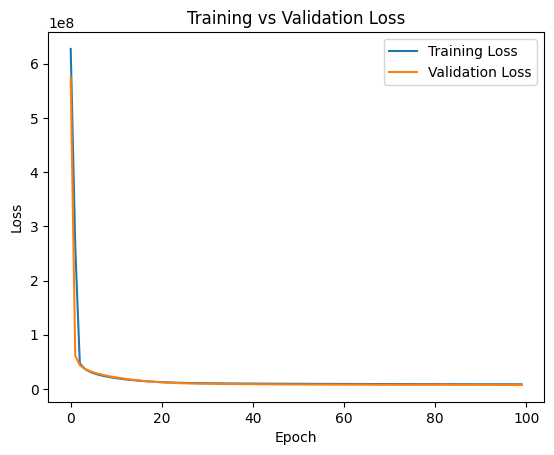

In [ ]:
#visualising hwo training progressed

import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label = 'Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()


Model learns rapidly in early epochs 0-20

Gradual flattening epochs 20-11 as improvements get smaller and smaller (ball settles)

Training and validation loss almost identical so the model generalises well to unseen data and no overfitting

The curve looks slightly decreasing at epoch 100 so could potentially benefit from more epochs

In [ ]:
#evaluation
from sklearn.metrics import mean_absolute_error

predictions = model.predict(test_X)
mae = mean_absolute_error(test_y, predictions)
print(f"Mean Absolute Error: £{mae:.2f}")

68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Mean Absolute Error: £1818.45


The model predicts BMW prices to within £1834 on average across your test set

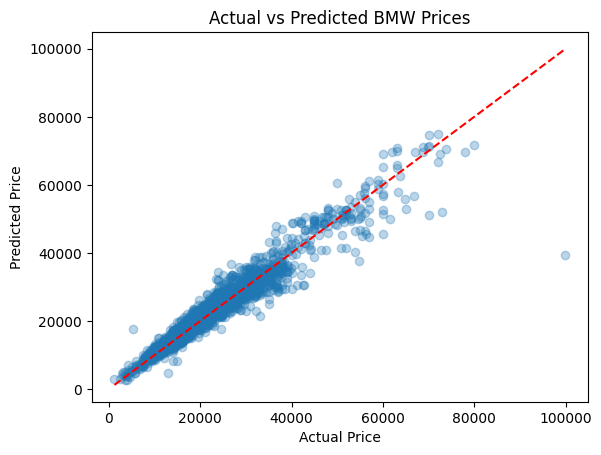

In [ ]:
import numpy as np

plt.scatter(test_y, predictions, alpha=0.3)
plt.plot([test_y.min(), test_y.max()], [test_y.min(), test_y.max()], 'r--')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted BMW Prices')
plt.show()


The model is less confident on expensive cars which makes sense as there are less of them in training data

We can try to improve model by increasing epochs based on what we have seen

In [ ]:
# Rebuild the model from scratch
model = keras.Sequential([
    layers.Dense(64, activation='relu', input_shape=(train_X.shape[1],)),
    layers.Dense(32, activation='relu'),
    layers.Dense(16, activation='relu'),
    layers.Dense(1)
])

model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mean_absolute_error'])

train_2 = model.fit(
    train_X, train_y,
    epochs=200,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)


Epoch 1/200


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


216/216 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 620837120.0000 - mean_absolute_error: 22221.7031 - val_loss: 542345728.0000 - val_mean_absolute_error: 20611.5625
Epoch 2/200
216/216 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 219186560.0000 - mean_absolute_error: 11166.8203 - val_loss: 54355868.0000 - val_mean_absolute_error: 4854.4321
Epoch 3/200
216/216 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 43829156.0000 - mean_absolute_error: 4365.7188 - val_loss: 40919784.0000 - val_mean_absolute_error: 4068.9846
Epoch 4/200
216/216 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 35038692.0000 - mean_absolute_error: 3767.7383 - val_loss: 35155672.0000 - val_mean_absolute_error: 3738.1882
Epoch 5/200
216/216 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 30395662.0000 - mean_absolute_error: 3484.8599 - val_loss: 31405404.0000 - val_mean_absolute_error: 3446.4949
Epoch 6/200
216/216 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 27169036.0000 - mean_absolute_error: 3282.4414 - val_loss: 28510624.0000 - val_mean_absolu

In [ ]:
predictions = model.predict(test_X)
mae = mean_absolute_error(test_y, predictions)
print(f"Mean Absolute Error: £{mae:.2f}")

68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Mean Absolute Error: £1753.33


Mean absolute error decreased to 1730.59 by increasing epochs

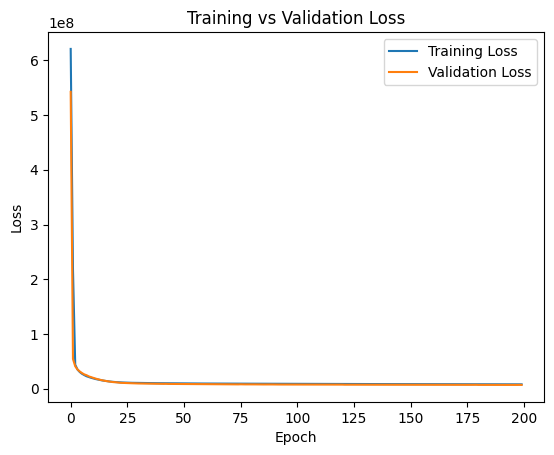

In [ ]:
plt.plot(train_2.history['loss'], label='Training Loss')
plt.plot(train_2.history['val_loss'], label = 'Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()

In [ ]:
# Rebuild the model from scratch
model = keras.Sequential([
    layers.Dense(64, activation='relu', input_shape=(train_X.shape[1],)),
    layers.Dense(32, activation='relu'),
    layers.Dense(16, activation='relu'),
    layers.Dense(1)
])

model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mean_absolute_error'])

#coding for 300 epochs
train_3 = model.fit(
    train_X, train_y,
    epochs=300,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor='val_loss',    # watch the validation loss
    patience=10,           # stop if no improvement for 10 epochs
    restore_best_weights=True  # keep the best version of the model
)


Epoch 1/300


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


216/216 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 630930880.0000 - mean_absolute_error: 22422.0234 - val_loss: 595269504.0000 - val_mean_absolute_error: 21681.0508
Epoch 2/300
216/216 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 307142784.0000 - mean_absolute_error: 14013.3525 - val_loss: 71868784.0000 - val_mean_absolute_error: 5519.9233
Epoch 3/300
216/216 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 50356708.0000 - mean_absolute_error: 4747.2671 - val_loss: 45752032.0000 - val_mean_absolute_error: 4332.3086
Epoch 4/300
216/216 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 39218176.0000 - mean_absolute_error: 4057.5132 - val_loss: 38755432.0000 - val_mean_absolute_error: 3937.9236
Epoch 5/300
216/216 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 33670396.0000 - mean_absolute_error: 3702.8547 - val_loss: 34411820.0000 - val_mean_absolute_error: 3636.3657
Epoch 6/300
216/216 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 29811180.0000 - mean_absolute_error: 3433.6519 - val_loss: 31082044.0000 - val_mean_absolu

68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
Mean Absolute Error: £1713.63
Training stopped at epoch: 300


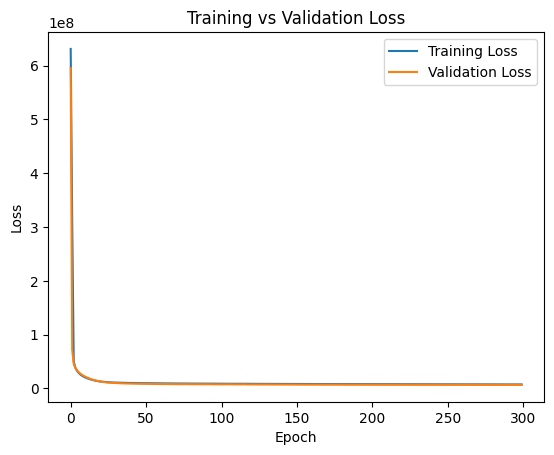

In [ ]:
predictions = model.predict(test_X)
mae = mean_absolute_error(test_y, predictions)
print(f"Mean Absolute Error: £{mae:.2f}")

print(f"Training stopped at epoch: {len(train_3.history['loss'])}")
#see which epoch we stopped at

plt.plot(train_3.history['loss'], label='Training Loss')
plt.plot(train_3.history['val_loss'], label = 'Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()

The model stopped at 300 epochs so was still improving lets try just max at 1000 epochs as likely to stop at some point up until then

In [ ]:
# Rebuild the model from scratch
model = keras.Sequential([
    layers.Dense(64, activation='relu', input_shape=(train_X.shape[1],)),
    layers.Dense(32, activation='relu'),
    layers.Dense(16, activation='relu'),
    layers.Dense(1)
])

model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mean_absolute_error'])

#coding for 1000 epochs
train_4 = model.fit(
    train_X, train_y,
    epochs=1000,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor='val_loss',    # watch the validation loss
    patience=10,           # stop if no improvement for 10 epochs
    restore_best_weights=True  # keep the best version of the model
)


Epoch 1/1000


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


216/216 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 625069952.0000 - mean_absolute_error: 22298.4961 - val_loss: 563064640.0000 - val_mean_absolute_error: 21039.1094
Epoch 2/1000
216/216 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 250318528.0000 - mean_absolute_error: 12251.0693 - val_loss: 59081824.0000 - val_mean_absolute_error: 5076.2598
Epoch 3/1000
216/216 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 47049688.0000 - mean_absolute_error: 4582.2065 - val_loss: 43529200.0000 - val_mean_absolute_error: 4215.7310
Epoch 4/1000
216/216 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 37388704.0000 - mean_absolute_error: 3943.5645 - val_loss: 37298840.0000 - val_mean_absolute_error: 3806.8875
Epoch 5/1000
216/216 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 32286110.0000 - mean_absolute_error: 3586.6650 - val_loss: 33203208.0000 - val_mean_absolute_error: 3607.2957
Epoch 6/1000
216/216 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 28738990.0000 - mean_absolute_error: 3362.9126 - val_loss: 30160952.0000 - val_mean_a

68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Mean Absolute Error: £1599.33
Training stopped at epoch: 1000


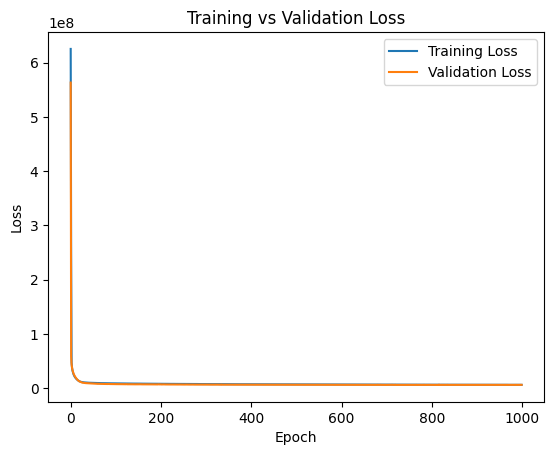

In [ ]:
predictions = model.predict(test_X)
mae = mean_absolute_error(test_y, predictions)
print(f"Mean Absolute Error: £{mae:.2f}")

print(f"Training stopped at epoch: {len(train_4.history['loss'])}")
#see which epoch we stopped at

plt.plot(train_4.history['loss'], label='Training Loss')
plt.plot(train_4.history['val_loss'], label = 'Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()

In [ ]:
print(f"Final training loss: {train_4.history['loss'][-1]:.2f}")
print(f"Final validation loss: {train_4.history['val_loss'][-1]:.2f}")

Final training loss: 6115983.50
Final validation loss: 6104848.00


The chart showed model converged very quickly in first 50 epochs then flatlined for remaining 950 epochs yet early stopping never triggered. Therefore, the validation loss still making tiny improvements

We can fix this by adding a min_delta parmeter to early stopping= sets a minimum threshold for 'meaningful improvement'

In [ ]:
# Rebuild the model from scratch
model = keras.Sequential([
    layers.Dense(64, activation='relu', input_shape=(train_X.shape[1],)),
    layers.Dense(32, activation='relu'),
    layers.Dense(16, activation='relu'),
    layers.Dense(1)
])

model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mean_absolute_error'])

#coding for 1000 epochs
train_5 = model.fit(
    train_X, train_y,
    epochs=1000,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    min_delta=100,         # improvements smaller than this don't count
    restore_best_weights=True
)

Epoch 1/1000


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


216/216 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 625003840.0000 - mean_absolute_error: 22297.6523 - val_loss: 568055040.0000 - val_mean_absolute_error: 21127.4805
Epoch 2/1000
216/216 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 268276064.0000 - mean_absolute_error: 12819.5820 - val_loss: 61993640.0000 - val_mean_absolute_error: 5058.8276
Epoch 3/1000
216/216 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 47299960.0000 - mean_absolute_error: 4577.9941 - val_loss: 43676976.0000 - val_mean_absolute_error: 4217.7783
Epoch 4/1000
216/216 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 37558592.0000 - mean_absolute_error: 3947.2771 - val_loss: 37568528.0000 - val_mean_absolute_error: 3849.1589
Epoch 5/1000
216/216 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 32608750.0000 - mean_absolute_error: 3615.6008 - val_loss: 33762464.0000 - val_mean_absolute_error: 3712.5449
Epoch 6/1000
216/216 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 29267294.0000 - mean_absolute_error: 3429.3157 - val_loss: 30637362.0000 - val_mean_a

In [ ]:
print(f"Training stopped at epoch: {len(train_5.history['loss'])}")
#see which epoch we stopped at


Training stopped at epoch: 1000


trying a different approach than adding epochs as it isnt bottoming out and taking time

instead trying to remove a suspicious outloier we had at £123,456 car and engine size of 0 confusing model

In [ ]:
# Remove price outliers
print(f"Rows before: {len(df)}")
df = df[df['price'] < 100000] #removing if price >100,000
df = df[df['engineSize'] > 0]
print(f"Rows after: {len(df)}")

Rows before: 10781
Rows after: 10733


Now rerunning everything with 100 epochs and removed outlier

In [ ]:
# Rebuild the model from scratch
model = keras.Sequential([
    layers.Dense(64, activation='relu', input_shape=(train_X.shape[1],)),
    layers.Dense(32, activation='relu'),
    layers.Dense(16, activation='relu'),
    layers.Dense(1)
])

model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mean_absolute_error'])

#coding for 100 epochs
train_no_outliers = model.fit(
    train_X, train_y,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


216/216 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 618147392.0000 - mean_absolute_error: 22166.8535 - val_loss: 530599616.0000 - val_mean_absolute_error: 20358.5957
Epoch 2/100
216/216 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 205302512.0000 - mean_absolute_error: 10716.7266 - val_loss: 52791688.0000 - val_mean_absolute_error: 4815.1387
Epoch 3/100
216/216 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 43027428.0000 - mean_absolute_error: 4315.3940 - val_loss: 40773228.0000 - val_mean_absolute_error: 4068.4573
Epoch 4/100
216/216 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 34968388.0000 - mean_absolute_error: 3776.0601 - val_loss: 35323896.0000 - val_mean_absolute_error: 3715.6467
Epoch 5/100
216/216 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 30553310.0000 - mean_absolute_error: 3492.0251 - val_loss: 31627402.0000 - val_mean_absolute_error: 3518.3713
Epoch 6/100
216/216 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 27518662.0000 - mean_absolute_error: 3309.7180 - val_loss: 28930784.0000 - val_mean_absolu

In [ ]:
predictions = model.predict(test_X)
mae = mean_absolute_error(test_y, predictions)
print(f"Mean Absolute Error: £{mae:.2f}")

68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Mean Absolute Error: £1841.62


MAE went up slightly so outliers werent causing as much of a problem as we thought.

Instead we can try a bigger network starting with 128 neurons in the first hidden layer as this gives the network more capacity to learn complex relationships

In [ ]:
model = keras.Sequential([
    layers.Dense(128, activation='relu', input_shape=(train_X.shape[1],)),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(16, activation='relu'),
    layers.Dense(1)
])

model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mean_absolute_error'])

#coding for 100 epochs
train_morelayers = model.fit(
    train_X, train_y,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


216/216 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 425975328.0000 - mean_absolute_error: 16640.3672 - val_loss: 48911076.0000 - val_mean_absolute_error: 4426.4238
Epoch 2/100
216/216 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 34979564.0000 - mean_absolute_error: 3703.7646 - val_loss: 31610118.0000 - val_mean_absolute_error: 3503.5483
Epoch 3/100
216/216 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 25785320.0000 - mean_absolute_error: 3183.8853 - val_loss: 25668626.0000 - val_mean_absolute_error: 3162.7085
Epoch 4/100
216/216 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 21533994.0000 - mean_absolute_error: 2907.0818 - val_loss: 21708282.0000 - val_mean_absolute_error: 2864.4192
Epoch 5/100
216/216 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 18633766.0000 - mean_absolute_error: 2678.4868 - val_loss: 18814704.0000 - val_mean_absolute_error: 2667.3655
Epoch 6/100
216/216 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 16451032.0000 - mean_absolute_error: 2513.5017 - val_loss: 17079006.0000 - val_mean_absolute_e

In [ ]:
predictions = model.predict(test_X)
mae = mean_absolute_error(test_y, predictions)
print(f"Mean Absolute Error: £{mae:.2f}")

68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
Mean Absolute Error: £1758.51


slight improvement but overall best result from 1000 epochs. Usually would conduct a GRID SEARCH
essentially a sensitivity analysis e.g.

number of layers - 2,3,4 hidden layers
number of neurons - 32,64,128 per layer
learning rate- 0.001, 0.0001, 0.00001
batch size - 16,32,64
activation function - relu, tanh, sigmoid

Instead of manually trying different architectures like we did, it KerasTuner automates search across all combinations
However different to random forests, neural networks are much more expensive to train (can take LOADS of time). This is why in practise people use Random Search or Bayesian Optimisation for neural networks rather than full Grid Search. This finds good solutions without exhuastively trying each combination.Cloud computing becomes important as run searches on powerful GPU servers rather than a laptop.